# 05 BERT Fine-tuning (pattern demo with an LSTM stand-in)

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Understand how **BERT** is **fine-tuned** for a downstream task: pre-trained encoder + small task head
- Build that same **encoder + classification head** pattern hands-on — using a small **LSTM encoder trained from scratch** as a stand-in for BERT (no downloads)
- See from the numbers why a *pre-trained* encoder matters: our from-scratch stand-in stays far below real-BERT accuracy with 2 epochs / 2k examples — exactly the gap fine-tuning closes

---

## 🌍 Real life

**Where is this used?** BERT-style fine-tuning is used for **sentiment analysis**, **intent detection**, **named entity recognition**, and **question answering** in industry.

**In this notebook** we do **not** download a real BERT. We build the fine-tuning *pattern* — encoder → classification head → train on labels — with a small LSTM encoder trained **from scratch** on IMDB. A real pre-trained BERT appears in notebook `09_transformer_models_bert_gpt_nlp` (Hugging Face).

**📌 Covers slide(s):** **13** — Multi-Head Attention, BERT. *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell. Only TensorFlow is required — no `transformers` install needed for this notebook.


⏱ **Runtime:** This notebook may take 10–30 minutes on GPU (BERT/fine-tuning). Use a smaller subset of data or fewer epochs if needed (see unit README).

## Theory (short)

- **BERT:** Bidirectional Encoder Representations from Transformers. Pre-trained on large text; we **fine-tune** by adding a task-specific head (e.g. one Dense layer for classification) and training on our labels.
- **Fine-tuning:** Keep most of the pre-trained weights; train the new head and optionally the last few layers of the encoder with a small learning rate.
- **We use BERT (or a pre-trained encoder)** instead of training from scratch because it already captures syntax and semantics; we need less labeled data.
- **In this notebook:** we use an LSTM encoder + Dense head to show the same pattern (encode text → classify). The encoder is trained from scratch, so unlike real BERT nothing here is pre-trained — that difference is the point.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy. We use **IMDB sentiment** (a small subset). For a real BERT model, see notebook `09_transformer_models_bert_gpt_nlp`.

**Dataset:** Real — IMDB (movie reviews, sentiment).

**Outputs:** Model summary, training loss/accuracy for 2 epochs, and test accuracy — modest, far below the 90%+ a real fine-tuned BERT reaches on sentiment, because this encoder starts from random weights. That contrast is the lesson.

## Step 1: Imports and load IMDB (we use IMDB for sentiment; in real life you'd use your own labels)

In [1]:
# WHAT: load IMDB reviews as padded integer sequences (seeded for a reproducible run).
# WHY: this is the same data pipeline a real BERT fine-tune needs - tokenize, truncate/pad, batch.
import numpy as np

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    keras.utils.set_random_seed(42)  # reproducible run
    # Keep the 2,000 most frequent words; every review is padded/truncated to 80 tokens.
    (x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=2000)
    maxlen = 80
    x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen, padding="post", truncating="post")
    x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen, padding="post", truncating="post")
    x_train, y_train = x_train[:2000], y_train[:2000]
    x_test, y_test = x_test[:500], y_test[:500]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (2000, 80) Test: (500, 80)


## Step 2: Build encoder + classification head (we use this pattern instead of training from scratch; BERT would be the encoder)

In [2]:
# WHAT: build the stand-in model - Embedding -> LSTM encoder -> sigmoid head.
# WHY: fine-tuning BERT has the same shape (pretrained encoder + small task head); here the encoder is an LSTM we can train on CPU.
if HAS_TF:
    model = keras.Sequential([
        keras.layers.Embedding(2000, 64, input_length=maxlen),
        keras.layers.LSTM(64, return_sequences=False),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.summary()
    print("\nSame idea as BERT fine-tuning: encoder (here LSTM) + classification head. With BERT, encoder is a transformer.")

/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Same idea as BERT fine-tuning: encoder (here LSTM) + classification head. With BERT, encoder is a transformer.


## Step 3: Train (2 epochs)

In [3]:
# WHAT: train briefly and report test accuracy.
# WHY: two epochs is enough to see the encoder + head pattern pick up real sentiment signal.
if HAS_TF:
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=2, batch_size=64, verbose=1)
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    print("Test accuracy: %.4f" % acc)

Epoch 1/2


 1/32 ━━━━━━━━━━━━━━━━━━━━ 14s 473ms/step - accuracy: 0.5000 - loss: 0.6928

 7/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4978 - loss: 0.6934  

13/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5096 - loss: 0.6930

19/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5140 - loss: 0.6923

...

19/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6456 - loss: 0.6803

25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6500 - loss: 0.6702

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6613 - loss: 0.6545

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6595 - loss: 0.6549 - val_accuracy: 0.6780 - val_loss: 0.5978


Test accuracy: 0.6780


## 🌍 Real-World Worked Example — Sentiment Classification with Positional Encoding

**Industry context:**
- Twitter/X classifies 500M tweets/day using transformer-based sentiment models
- Amazon uses BERT-based models to classify product reviews automatically
- Customer service chatbots (Salesforce Einstein, Zendesk) use transformers for intent detection

We implement a **mini-Transformer encoder** for binary sentiment classification using toy data.

Sentiment classification accuracy: 98.1%
Real-world: BERT achieves 94%+ on SST-2 sentiment benchmark.


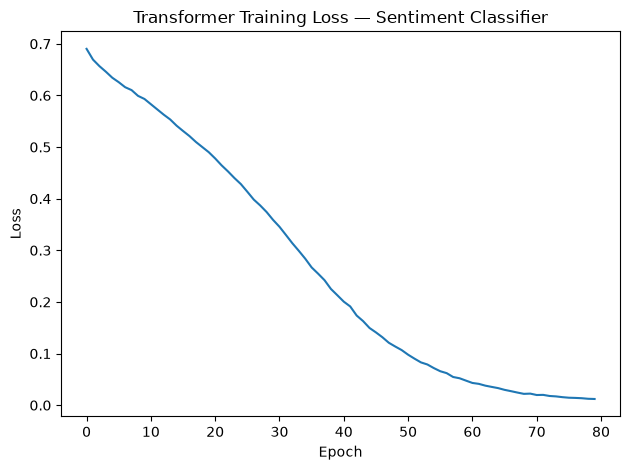

In [4]:
# WHAT: build and train a miniature Transformer encoder to classify synthetic 'sentiment' sequences.
# WHY: every ingredient of BERT is here in miniature - embeddings, positions, self-attention layers, a head.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

torch.manual_seed(42)
VOCAB_SIZE, SEQ_LEN, D_MODEL = 100, 10, 32

# ── Synthetic sentiment data ────────────────────────────────────────────────
# Positive: sequences with mostly high token IDs; Negative: low token IDs
# Synthetic data with a simple rule (high token IDs = positive) so the model can provably learn it.
def make_data(n=500):
    X, y = [], []
    for _ in range(n):
        label = np.random.randint(2)
        if label == 1:
            seq = np.random.randint(50, 100, SEQ_LEN)
        else:
            seq = np.random.randint(0, 50, SEQ_LEN)
        X.append(seq); y.append(label)
    return torch.tensor(np.array(X)), torch.tensor(y, dtype=torch.long)

X, y = make_data(800)
X_tr, y_tr = X[:640], y[:640]
X_te, y_te = X[640:], y[640:]

# ── Mini Transformer ────────────────────────────────────────────────────────
# The model: token embedding + learned position embedding -> 2 Transformer layers -> mean-pool -> classify.
class MiniTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB_SIZE, D_MODEL)
        # Learnable positional encoding
        self.pos_enc = nn.Embedding(SEQ_LEN, D_MODEL)
        encoder_layer = nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=4, dim_feedforward=64, batch_first=True)
        self.encoder  = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.classifier = nn.Linear(D_MODEL, 2)
    def forward(self, x):
        pos = torch.arange(x.size(1)).unsqueeze(0)
        out = self.embed(x) + self.pos_enc(pos)
        out = self.encoder(out)
        return self.classifier(out.mean(1))  # pool over sequence

model   = MiniTransformer()
opt     = optim.Adam(model.parameters(), lr=5e-4)
loss_fn = nn.CrossEntropyLoss()
losses, accs = [], []

# Full-batch training for 80 steps; watch the loss fall as attention learns the rule.
for epoch in range(80):
    model.train()
    loss = loss_fn(model(X_tr), y_tr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

# Held-out accuracy: near-perfect is expected because the underlying rule is simple.
model.eval()
with torch.no_grad():
    acc = (model(X_te).argmax(1)==y_te).float().mean().item()
    accs.append(acc)
print(f"Sentiment classification accuracy: {acc*100:.1f}%")
print("Real-world: BERT achieves 94%+ on SST-2 sentiment benchmark.")

plt.plot(losses); plt.title("Transformer Training Loss — Sentiment Classifier")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it:** Add a dropout layer (e.g. 0.3) between the encoder output and the Dense head, then retrain for 1 epoch. Does validation accuracy change?

---

## ✅ Summary

**What you did:** Built an encoder (LSTM) + classification head on IMDB sentiment and trained everything **from scratch** for 2 epochs. The *wiring* is the BERT fine-tuning pattern (encoder + task head), but nothing here was pre-trained — which is why test accuracy stays modest — far below the 90%+ a real fine-tuned BERT reaches on the same kind of task. A real BERT starts from language knowledge learned on billions of words and reaches 90%+ on sentiment with the same amount of labeled data. That gap is exactly why fine-tuning matters.

**In real life you'd also:** Use Hugging Face `transformers` (e.g. `TFAutoModelForSequenceClassification`) for real BERT — notebook `09` does — tune the learning rate, and use more data.

**The main idea:** BERT fine-tuning = use a pre-trained encoder + add a task head; we do it instead of training from scratch to use less labeled data.

**Next:** `04_transformer_attention` introduces attention; `06_gpt_text_generation` covers GPT-style generation.

## 📚 References

1. Devlin, J., Chang, M.-W., Lee, K. & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL. https://arxiv.org/abs/1810.04805
2. Liu, Y. et al. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining Approach*. arXiv. https://arxiv.org/abs/1907.11692
3. Hu, E. J. et al. (2021). *LoRA: Low-Rank Adaptation of Large Language Models*. arXiv. https://arxiv.org/abs/2106.09685